### import libraries

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from XLO_sim import tools

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)
figs_path = os.path.join(base_directory, 'figs')
os.makedirs(figs_path, exist_ok=True)

initializing ocelot...


### load simulation (mono sweep) results

Mirrors `plot-mono-transmittance-vs-intensity.ipynb` cell 7 -- point `data_path` at whatever
`run_mono_sweep.py` output folder you want to compare (e.g. `../data/mono_sweep`).

In [2]:
data_path = "../data/mono_sweep_double_satellite"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
              'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

sim_transmittance = {}
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)
    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        T_values[i] = np.sum(arrays['I_int_thy_w_last']) / np.sum(arrays['I_int_thy_w_0'])
    sim_transmittance[E_seed_value] = (energy_values, T_values)

sorted(sim_transmittance.keys())

[0.1, 1, 5, 20, 30]

### load experimental data

Hand-digitized from `docs/Results_RSA_seeded.pdf` slide 9 ("Cu 20 um, self-seeded beam") --
see the header comment in the CSV for caveats (approximate, read off the chart by eye, not
a precision reference -- use for dip depth/width comparisons, not point-by-point fitting).

In [3]:
exp_df = pd.read_csv("../data/transmittance_seeded_uJ.csv", comment='#')
exp_energies_uJ = [float(c.split('uJ')[0]) for c in exp_df.columns if c != 'Photon_energy_eV']
exp_df.head()

,Photon_energy_eV,0.1uJ_transmittance,1uJ_transmittance,5uJ_transmittance,10uJ_transmittance,20uJ_transmittance,30uJ_transmittance,40uJ_transmittance,50uJ_transmittance
0,8000,0.410,0.413,0.397,0.404,0.404,0.403,0.400,0.400
1,8005,0.410,0.411,0.406,0.406,0.398,0.390,0.393,0.398
2,8010,0.409,0.408,0.401,0.403,0.394,0.383,0.388,0.383
3,8015,0.408,0.404,0.393,0.390,0.362,0.375,0.362,0.322
4,8020,0.406,0.400,0.390,0.378,0.322,0.310,0.320,0.338


### overlay: simulation vs. experiment, per pulse energy

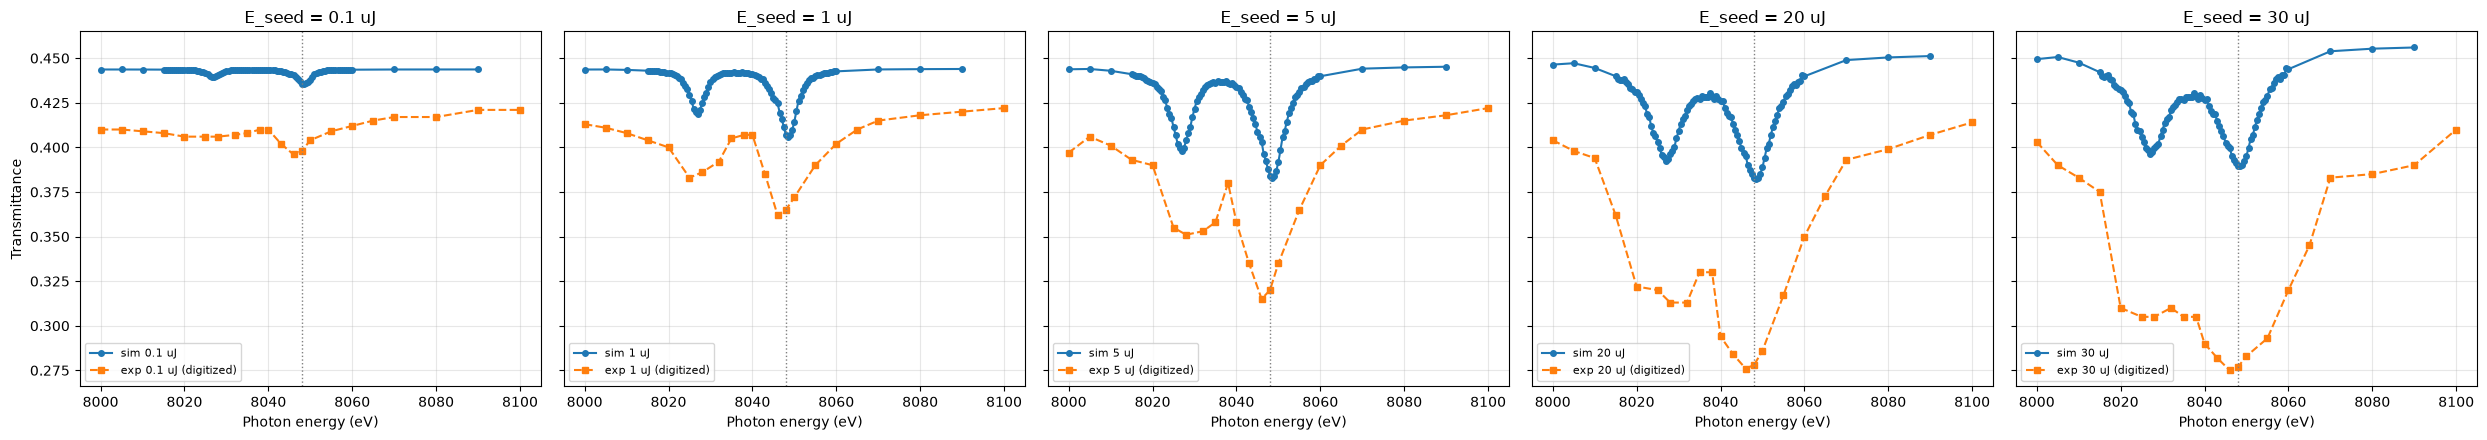

In [4]:
# Match each simulated E_seed to the nearest digitized experimental energy column.
sim_E_values = sorted(sim_transmittance.keys())

fig, axs = plt.subplots(1, len(sim_E_values), figsize=(5 * len(sim_E_values), 4.5), sharey=True)
if len(sim_E_values) == 1:
    axs = [axs]

for ax, E_seed_value in zip(axs, sim_E_values):
    energy_values, T_values = sim_transmittance[E_seed_value]
    ax.plot(energy_values, T_values, 'o-', color='tab:blue', ms=4, label=f'sim {E_seed_value:g} uJ')

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
            's--', color='tab:orange', ms=4, label=f'exp {E_exp:g} uJ (digitized)')

    ax.axvline(hwKalpha1N, color='grey', ls=':', lw=1)
    ax.set_xlabel('Photon energy (eV)')
    ax.set_title(f'E_seed = {E_seed_value:g} uJ')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('Transmittance')
plt.tight_layout()
plt.savefig(os.path.join(figs_path, 'mono_transmittance_sim_vs_experiment.pdf'))
plt.show()

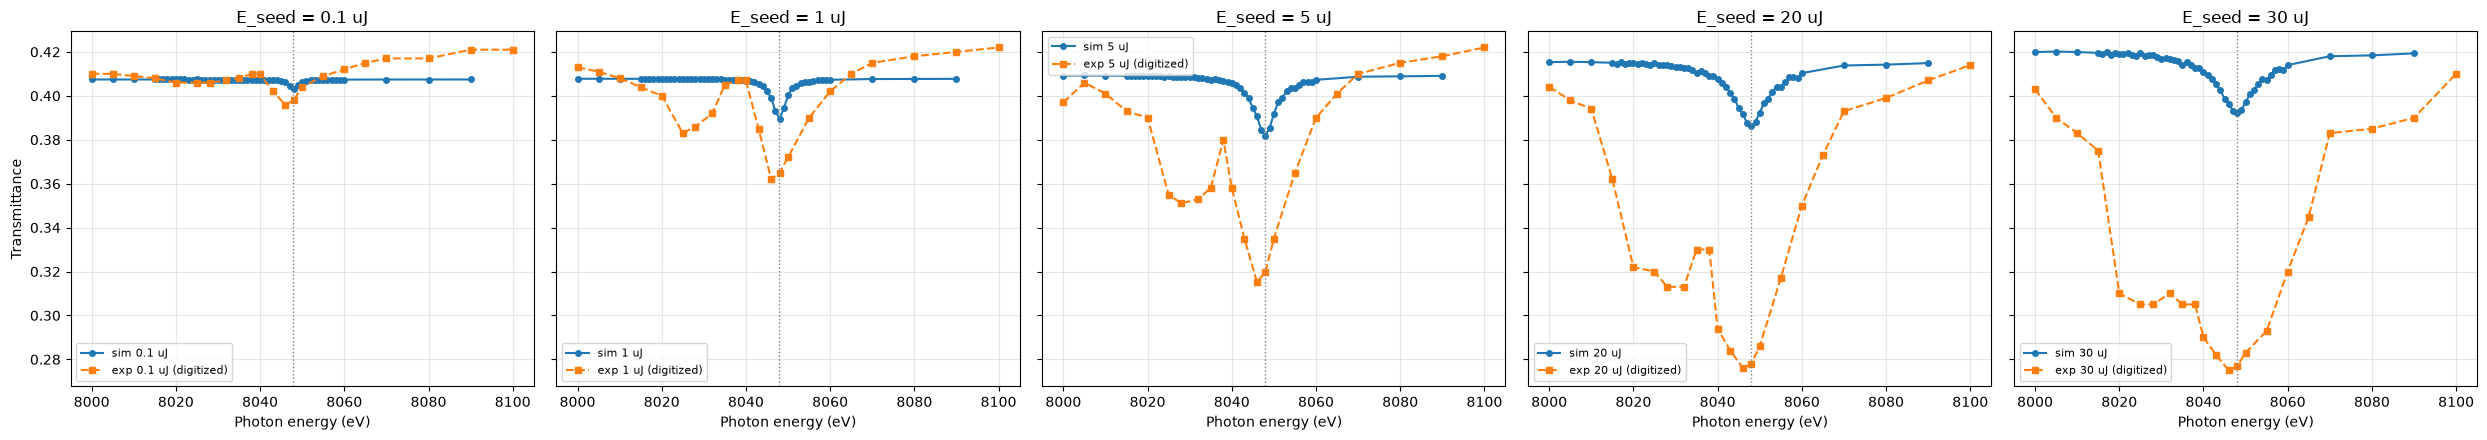

In [5]:
data_path = "../data/production_sweep_mono_24437094/Cu-seed-mono-SASE-original"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
              'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

sim_transmittance = {}
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)
    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        T_values[i] = np.sum(arrays['I_int_thy_w_last']) / np.sum(arrays['I_int_thy_w_0'])
    sim_transmittance[E_seed_value] = (energy_values, T_values)

sorted(sim_transmittance.keys())

# Match each simulated E_seed to the nearest digitized experimental energy column.
sim_E_values = sorted(sim_transmittance.keys())

fig, axs = plt.subplots(1, len(sim_E_values), figsize=(5 * len(sim_E_values), 4.5), sharey=True)
if len(sim_E_values) == 1:
    axs = [axs]

for ax, E_seed_value in zip(axs, sim_E_values):
    energy_values, T_values = sim_transmittance[E_seed_value]
    ax.plot(energy_values, T_values, 'o-', color='tab:blue', ms=4, label=f'sim {E_seed_value:g} uJ')

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
            's--', color='tab:orange', ms=4, label=f'exp {E_exp:g} uJ (digitized)')

    ax.axvline(hwKalpha1N, color='grey', ls=':', lw=1)
    ax.set_xlabel('Photon energy (eV)')
    ax.set_title(f'E_seed = {E_seed_value:g} uJ')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('Transmittance')
plt.tight_layout()
plt.savefig(os.path.join(figs_path, 'mono_transmittance_sim_vs_experiment.pdf'))
plt.show()

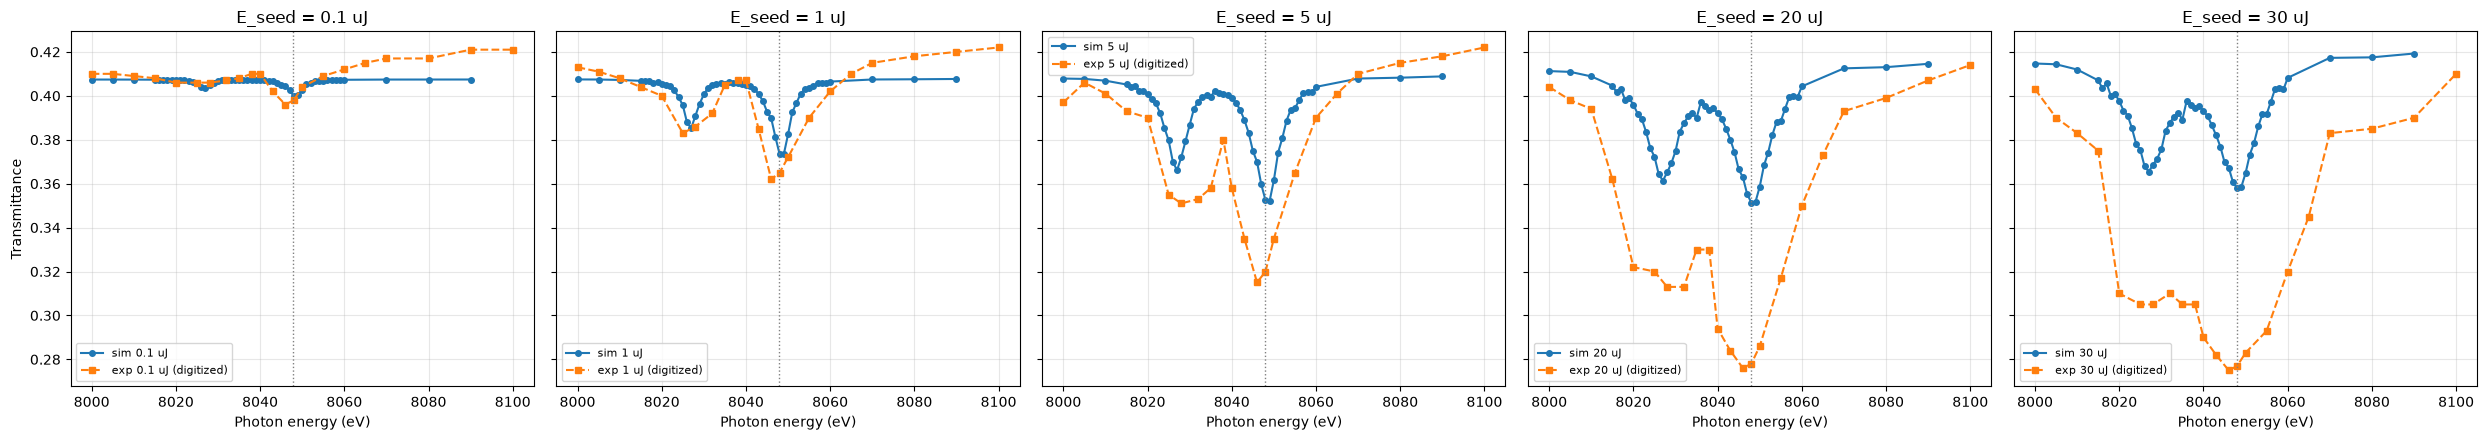

In [6]:
data_path = "../data/production_sweep_mono_24437094/Cu-seed-mono-SASE-double-satellite"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
              'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

sim_transmittance = {}
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)
    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        T_values[i] = np.sum(arrays['I_int_thy_w_last']) / np.sum(arrays['I_int_thy_w_0'])
    sim_transmittance[E_seed_value] = (energy_values, T_values)

sorted(sim_transmittance.keys())

# Match each simulated E_seed to the nearest digitized experimental energy column.
sim_E_values = sorted(sim_transmittance.keys())

fig, axs = plt.subplots(1, len(sim_E_values), figsize=(5 * len(sim_E_values), 4.5), sharey=True)
if len(sim_E_values) == 1:
    axs = [axs]

for ax, E_seed_value in zip(axs, sim_E_values):
    energy_values, T_values = sim_transmittance[E_seed_value]
    ax.plot(energy_values, T_values, 'o-', color='tab:blue', ms=4, label=f'sim {E_seed_value:g} uJ')

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
            's--', color='tab:orange', ms=4, label=f'exp {E_exp:g} uJ (digitized)')

    ax.axvline(hwKalpha1N, color='grey', ls=':', lw=1)
    ax.set_xlabel('Photon energy (eV)')
    ax.set_title(f'E_seed = {E_seed_value:g} uJ')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('Transmittance')
plt.tight_layout()
plt.savefig(os.path.join(figs_path, 'mono_transmittance_sim_vs_experiment.pdf'))
plt.show()

In [7]:
import yaml
from collections import OrderedDict

def data_from_folder(folder_path, group_keys, aux_keys=(), reverse=True):
    if isinstance(group_keys, str):
        group_keys = (group_keys,)

    accumulated = {}
    aux_data = None
    total_n_reps = None

    for runs_folder in os.listdir(folder_path):
        runs_path = os.path.join(folder_path, runs_folder)
        if not os.path.isdir(runs_path):
            continue

        yaml_file = next((f for f in os.listdir(runs_path) if f.endswith('.yaml')), None)
        if yaml_file is None:
            print(f"No YAML file found in {runs_path}")
            continue
        with open(os.path.join(runs_path, yaml_file), 'r') as f:
            yaml_data = yaml.safe_load(f)

        group_values = tuple(yaml_data[k] for k in group_keys)
        aux_data = [yaml_data[k] for k in aux_keys]

        sums, sumsqs, counts, axes = {}, {}, {}, {}
        n_reps = 0
        for file_name in os.listdir(runs_path):
            if not file_name.endswith('.npz'):
                continue
            print(file_name)
            data = np.load(os.path.join(runs_path, file_name))
            file_n_reps = int(data['n_reps'])
            n_reps += file_n_reps

            sum_keys = {n[:-len('_sum')] for n in data.files if n.endswith('_sum')}
            for key in sum_keys:
                chunk_sum = data[f"{key}_sum"]
                chunk_count = (data[f"{key}_count"] if f"{key}_count" in data.files
                               else np.full(chunk_sum.shape, file_n_reps, dtype=float))
                bad = np.isnan(chunk_sum)
                if np.any(bad):
                    chunk_sum = np.where(bad, 0, chunk_sum)
                    chunk_count = np.where(bad, 0, chunk_count)
                sums[key] = sums.get(key, 0) + chunk_sum
                counts[key] = counts.get(key, 0) + chunk_count
                if f"{key}_sumsq" in data.files:
                    chunk_sumsq = np.where(bad, 0, data[f"{key}_sumsq"])
                    sumsqs[key] = sumsqs.get(key, 0) + chunk_sumsq

            for array_name in data.files:
                if array_name in ('n_reps',) or array_name.endswith(('_sum', '_sumsq', '_count')):
                    continue
                axes[array_name] = data[array_name]

        if n_reps == 0:
            print(f"No .npz chunk files found in {runs_path}")
            continue

        group_arrays = dict(axes)
        for key, total_sum in sums.items():
            count = counts[key]
            n_starved = int((count == 0).sum())
            if n_starved:
                print(f"Warning: {key} in {runs_path} has {n_starved} element(s) with no valid "
                      f"(non-NaN) repetitions -- left as NaN")
            count_safe = np.where(count > 0, count, 1)
            mean = np.where(count > 0, total_sum / count_safe, np.nan)
            group_arrays[key] = mean
            if key in sumsqs:
                variance = np.where(count > 0, sumsqs[key] / count_safe - np.abs(mean) ** 2, np.nan)
                group_arrays[f"{key}_std"] = np.sqrt(np.clip(variance, 0, None))

        node = accumulated
        for gv in group_values[:-1]:
            node = node.setdefault(gv, {})
        node[group_values[-1]] = group_arrays
        total_n_reps = n_reps

    def sort_level(level_dict, depth):
        items = sorted(level_dict.items(), key=lambda kv: kv[0], reverse=(reverse if depth == 0 else False))
        if depth + 1 < len(group_keys):
            return OrderedDict((k, sort_level(v, depth + 1)) for k, v in items)
        return OrderedDict(items)

    sorted_accumulated_arrays = sort_level(accumulated, 0)
    return sorted_accumulated_arrays, aux_data, total_n_reps 


In [8]:
np.load("/Users/parkinpham/Programming/Physics/DESY_Internship/Cu-RSA-XFEL-Simulation/data/production_sweep_mono_24437094/Cu-seed-mono-SASE-double-satellite-grasp/runs_seed_20.0_uJ__energy_8010.00_eV/run_at_seed_20.0_uJ__energy_8010.00_eV__reps_0-10_2026-09-06T14:29:54.npz")

BadZipFile: File is not a zip file

In [9]:
data_path = "../data/production_sweep_mono_24437094/Cu-seed-mono-SASE-double-satellite-grasp"

sorted_accumulated_arrays, aux_data, num_files = data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
              'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

sim_transmittance = {}
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)
    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        T_values[i] = np.sum(arrays['I_int_thy_w_last']) / np.sum(arrays['I_int_thy_w_0'])
    sim_transmittance[E_seed_value] = (energy_values, T_values)

sorted(sim_transmittance.keys())

# Match each simulated E_seed to the nearest digitized experimental energy column.
sim_E_values = sorted(sim_transmittance.keys())

fig, axs = plt.subplots(1, len(sim_E_values), figsize=(5 * len(sim_E_values), 4.5), sharey=True)
if len(sim_E_values) == 1:
    axs = [axs]

for ax, E_seed_value in zip(axs, sim_E_values):
    energy_values, T_values = sim_transmittance[E_seed_value]
    ax.plot(energy_values, T_values, 'o-', color='tab:blue', ms=4, label=f'sim {E_seed_value:g} uJ')

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
            's--', color='tab:orange', ms=4, label=f'exp {E_exp:g} uJ (digitized)')

    ax.axvline(hwKalpha1N, color='grey', ls=':', lw=1)
    ax.set_xlabel('Photon energy (eV)')
    ax.set_title(f'E_seed = {E_seed_value:g} uJ')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('Transmittance')
plt.tight_layout()
plt.savefig(os.path.join(figs_path, 'mono_transmittance_sim_vs_experiment.pdf'))
plt.show()

run_at_seed_5.0_uJ__energy_8021.00_eV__reps_0-10_2026-09-06T14:29:37.npz


BadZipFile: File is not a zip file

### off-resonance baseline check

Sim vs. experiment far-detuned transmittance (large |E - E_Kalpha1|) isolates the *non-resonant*
photoionization opacity (n * sigma_total * L via `sigma1_Ka1_2s/2p3/other`, thickness `zmax`), with
no RSA/Kalpha physics involved -- if this baseline itself is off, the cross-section/thickness inputs
(not the resonant model) are the first thing to check.

In [10]:
for E_seed_value in sim_E_values:
    energy_values, T_values = sim_transmittance[E_seed_value]
    off_res = np.abs(energy_values - hwKalpha1N) > 25
    sim_baseline = np.mean(T_values[off_res]) if off_res.any() else np.nan

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    exp_col = exp_df[f'{E_exp:g}uJ_transmittance']
    exp_off_res = np.abs(exp_df['Photon_energy_eV'] - hwKalpha1N) > 25
    exp_baseline = exp_col[exp_off_res].mean()

    print(f"E_seed={E_seed_value:>6g} uJ  sim baseline T={sim_baseline:.3f}   "
          f"exp baseline T={exp_baseline:.3f} (matched to {E_exp:g} uJ)")

E_seed=   0.1 uJ  sim baseline T=0.407   exp baseline T=0.413 (matched to 0.1 uJ)
E_seed=     1 uJ  sim baseline T=0.406   exp baseline T=0.412 (matched to 1 uJ)
E_seed=     5 uJ  sim baseline T=0.404   exp baseline T=0.405 (matched to 5 uJ)
E_seed=    20 uJ  sim baseline T=0.403   exp baseline T=0.388 (matched to 20 uJ)
E_seed=    30 uJ  sim baseline T=0.406   exp baseline T=0.381 (matched to 30 uJ)


### clean comparison: original vs. double-satellite pathway, sim vs. experiment

Two separate figures (`Cu-seed-mono-SASE-original`, then `Cu-seed-mono-SASE-double-satellite`),
each one row with a column per pulse energy. Both figures share the same y-axis scale so they
stay directly comparable side by side.

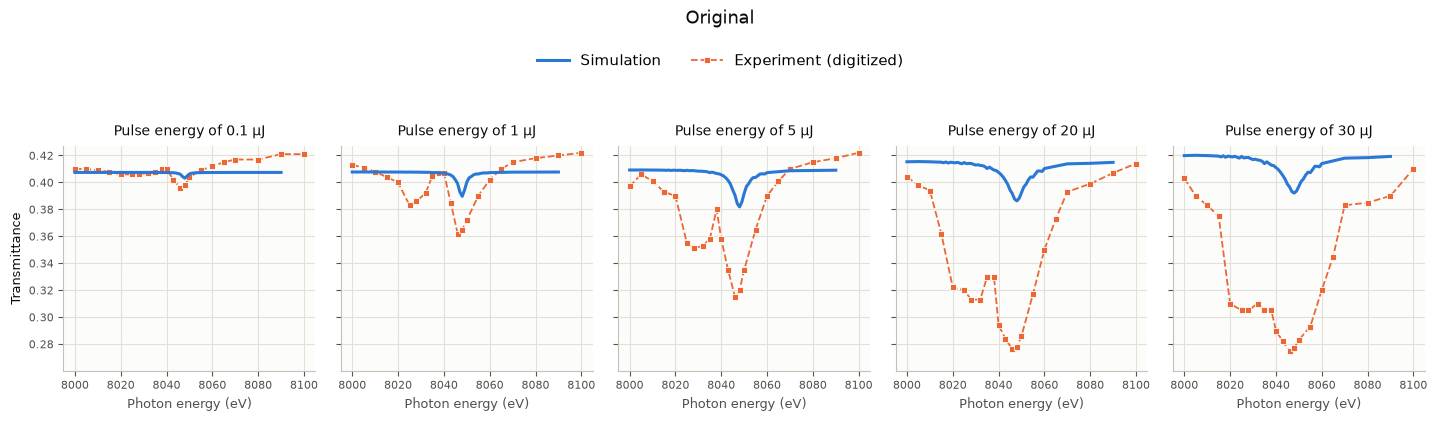

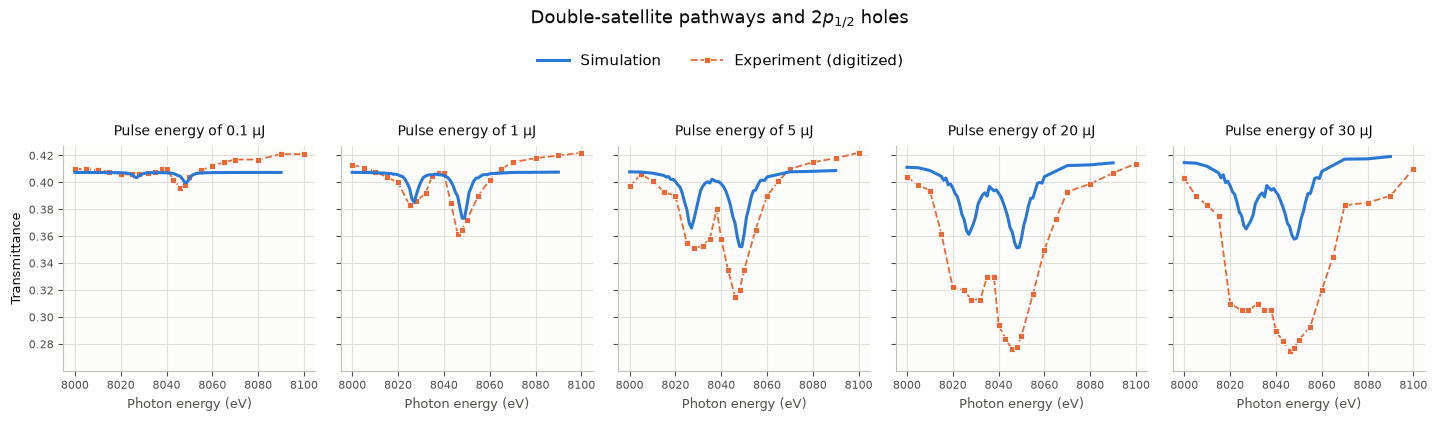

In [11]:
def load_sim_transmittance(data_path):
    sorted_accumulated_arrays, aux_data, _ = tools.data_from_folder(
        data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
        aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
                  'seed_duration_FWHM_t', 'hwKalpha1N'],
    )
    hwKalpha1N_ds = aux_data[-1]
    transmittance = {}
    for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
        energy_values = np.array(sorted(energy_arrays.keys()))
        T_values = np.array([
            np.sum(energy_arrays[e]['I_int_thy_w_last']) / np.sum(energy_arrays[e]['I_int_thy_w_0'])
            for e in energy_values
        ])
        transmittance[E_seed_value] = (energy_values, T_values)
    return transmittance, hwKalpha1N_ds


datasets = [
    ('Cu-seed-mono-SASE-original', 'Original'),
    ('Cu-seed-mono-SASE-double-satellite', 'Double-satellite pathways and $2p_{1/2}$ holes'),
]

dataset_data = []
for folder_name, title in datasets:
    path = f"../data/production_sweep_mono_24437094/{folder_name}"
    transmittance, hwKalpha1N_ds = load_sim_transmittance(path)
    dataset_data.append({'folder_name': folder_name, 'title': title,
                          'transmittance': transmittance, 'hwKalpha1N': hwKalpha1N_ds})

# Only compare pulse energies present in both datasets.
sim_E_common = sorted(set.intersection(*(set(ds['transmittance'].keys()) for ds in dataset_data)))

# Colors from the validated categorical palette (blue = simulation, orange = experiment).
COLOR_SIM = '#2a78d6'
COLOR_EXP = '#eb6834'
COLOR_GRID = '#e1e0d9'
COLOR_AXIS = '#c3c2b7'
COLOR_MUTED = '#898781'
COLOR_INK = '#0b0b0b'
COLOR_SECONDARY = '#52514e'

n_cols = len(sim_E_common)

# Shared y-limits across both figures so the two plots stay visually comparable.
all_sim_T = np.concatenate([T for ds in dataset_data for (_, T) in ds['transmittance'].values()])
all_exp_T = exp_df[[c for c in exp_df.columns if c != 'Photon_energy_eV']].to_numpy().ravel()
y_lo = min(all_sim_T.min(), np.nanmin(all_exp_T))
y_hi = max(all_sim_T.max(), np.nanmax(all_exp_T))
y_pad = 0.03 * (y_hi - y_lo)
y_lims = (y_lo - y_pad, y_hi + y_pad)

for ds in dataset_data:
    fig, axs = plt.subplots(1, n_cols, figsize=(2.9 * n_cols, 3.5), sharey=True)
    axs = np.atleast_1d(axs)

    for col_idx, E_seed_value in enumerate(sim_E_common):
        ax = axs[col_idx]
        energy_values, T_values = ds['transmittance'][E_seed_value]
        # Simulation is densely sampled -- render as a smooth line, no markers.
        sim_line, = ax.plot(energy_values, T_values, '-', color=COLOR_SIM, lw=2.2, zorder=3)

        # Experiment is sparsely digitized -- keep markers to show the real sample points.
        E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
        exp_line, = ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
                             '--', color=COLOR_EXP, lw=1.3,
                             marker='s', ms=4, mec='white', mew=0.6, zorder=2)

        ax.set_facecolor('#fcfcfb')
        ax.grid(color=COLOR_GRID, lw=0.8, zorder=0)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)
        for spine in ('left', 'bottom'):
            ax.spines[spine].set_color(COLOR_AXIS)
        ax.tick_params(colors=COLOR_SECONDARY, labelsize=8)

        ax.set_title(f'Pulse energy of {E_seed_value:g} µJ', fontsize=10, color=COLOR_INK, pad=8)
        ax.set_xlabel('Photon energy (eV)', fontsize=9, color=COLOR_SECONDARY)

    axs[0].set_ylabel('Transmittance', fontsize=9.5, color=COLOR_INK)
    axs[0].set_ylim(y_lims)

    fig.legend(
        [sim_line, exp_line], ['Simulation', 'Experiment (digitized)'],
        loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.1),
        fontsize=10.5, handlelength=2.2,
    )
    fig.suptitle(ds['title'], fontsize=13, color=COLOR_INK, y=1.19)

    plt.tight_layout(rect=(0, 0, 1, 1))
    plt.savefig(
        os.path.join(figs_path, f"mono_transmittance_sim_vs_experiment_{ds['folder_name']}.pdf"),
        bbox_inches='tight',
    )
    plt.show()